In [1]:
%autosave 90
%config Completer.use_jedi = False
from IPython.core.interactiveshell import InteractiveShell
from IPython.display import HTML

InteractiveShell.ast_node_interactivity = "all"
import glob
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

Autosaving every 90 seconds


# Fig1

In [3]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

(-0.3, 0.3)

<Axes: xlabel='mean difference', ylabel='-log10(q)'>

[Text(0.5, 1.0, 'C9-Patient - C9-Carrier'),
 Text(0, 0.5, '$-\\log_{10}(\\mathrm{adjusted\\ p\\text{-}value})$'),
 Text(0.5, 0, 'Mean difference')]

([Text(-0.19767235435724606, 19.967157807532516, 'SUMO1P1'),
  Text(-0.23167581367356765, 20.220890696500106, 'HOOK2'),
  Text(-0.17594681848820415, 58.789886088779355, 'SLC17A3'),
  Text(0.22087338565238313, 32.963548606672944, 'GP1BB'),
  Text(-0.2500240731824747, -3.255312949242157, 'MYRF'),
  Text(-0.22023592681752527, -3.255312949242157, 'SEPTIN9'),
  Text(-0.22177731776600867, -3.255312949242157, 'S100A8'),
  Text(-0.09446316803081367, 21.313213110837914, 'CACNA2D4'),
  Text(-0.15101001974000963, 91.77269877073977, 'CCDC88B'),
  Text(0.1991018218584497, 20.59642528410791, 'EVPL'),
  Text(-0.12725084256138663, 65.42305127134948, 'GRK2'),
  Text(-0.10169033365430913, 10.635839418573013, 'KRT17'),
  Text(-0.2074872667308618, -3.255312949242157, 'MED25'),
  Text(-0.1334008637457872, 42.6788623297183, 'IFFO1'),
  Text(0.20526241405873857, 6.783821139858311, 'PLAUR')],
 [Text(-0.19767235435724606, 19.967157807532516, ''),
  Text(-0.17594681848820415, 58.789886088779355, ''),
  Text(-0.

(-0.3, 0.3)

...

([Text(-0.1509837053442465, 10.038111301347133, 'MAG'),
  Text(0.12396917332691382, 24.853848581183502, 'RNPEPL1'),
  Text(0.11515553635050546, 22.665274566214475, 'SNX20'),
  Text(-0.04917844487241213, 4.041930625499953, 'FOXP1'),
  Text(0.10105177660086662, 28.673958954909143, 'SMPD5'),
  Text(0.08034571449205585, 10.745660713359989, 'ABHD16B'),
  Text(0.10853146798266733, 13.471716590764952, 'NUMBL'),
  Text(-0.05440228887818971, 7.757291424659579, 'PTPRF'),
  Text(0.09573662349542605, 16.29513890196088, 'MAZ'),
  Text(0.09395088733750595, 3.057466970557792, 'ANKRD18A'),
  Text(0.08750946220510347, 8.865174784375075, 'FAM201A'),
  Text(-0.013076266249398227, 14.551330745925519, 'POLR2M'),
  Text(0.03975619836302363, 21.684177742973034, 'TLX1NB'),
  Text(0.08369571160327394, 3.057466970557792, 'TLX1')],
 [Text(-0.1509837053442465, 10.038111301347133, ''),
  Text(0.12396917332691382, 24.853848581183502, ''),
  Text(0.11515553635050546, 22.665274566214475, ''),
  Text(-0.04917844487241

(-0.3, 0.3)

<Axes: xlabel='mean difference', ylabel='-log10(q)'>

[Text(0.5, 1.0, 'sALS - Control'),
 Text(0, 0.5, '$-\\log_{10}(\\mathrm{adjusted\\ p\\text{-}value})$'),
 Text(0.5, 0, 'Mean difference')]

([Text(-0.14773326095329803, 36.56197336061665, 'PON1'),
  Text(-0.1686598189696678, 10.590169259658758, 'LMTK3'),
  Text(0.16488092103996144, 34.827654466080936, 'CACNA2D4'),
  Text(0.18883790707751558, 17.157651545623878, 'SUMO1P1'),
  Text(0.1694006547905632, 24.485020470425177, 'STK11'),
  Text(0.16440678237843043, 8.90788928766493, 'MTIF3'),
  Text(0.15901724121328842, 1.9621722474953245, 'PRPSAP1'),
  Text(0.17382517332691383, 1.9621722474953245, 'CARS2'),
  Text(-0.09087569956668273, 24.384644918275164, 'LMTK3'),
  Text(-0.05666877852672125, 6.182576037252833, 'SLC17A3'),
  Text(0.1957672753972074, 52.86519148001937, 'RXRA'),
  Text(-0.05157475300914788, 32.65466840938784, 'SLC44A2'),
  Text(-0.08735208762638424, 76.91479457043184, 'WDR97'),
  Text(-0.06747508714492056, 15.438208332373527, 'SMIM24'),
  Text(-0.06405993163216178, 49.03857145405578, 'ARHGAP45')],
 [Text(-0.14773326095329803, 36.56197336061665, ''),
  Text(0.16488092103996144, 34.827654466080936, ''),
  Text(0.1694

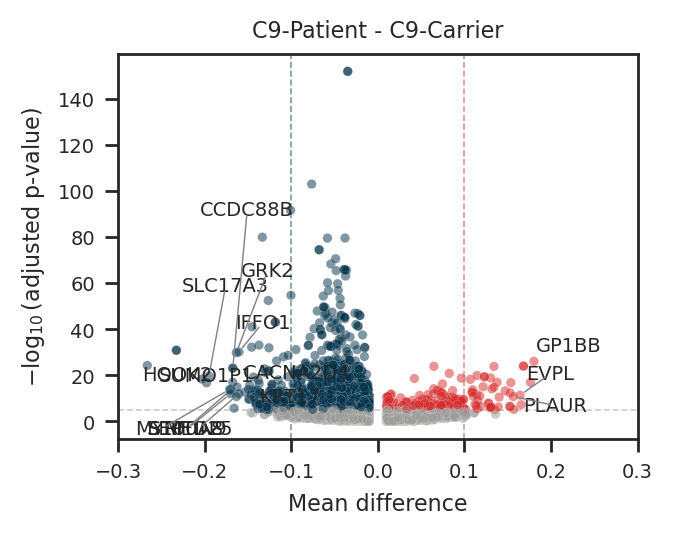

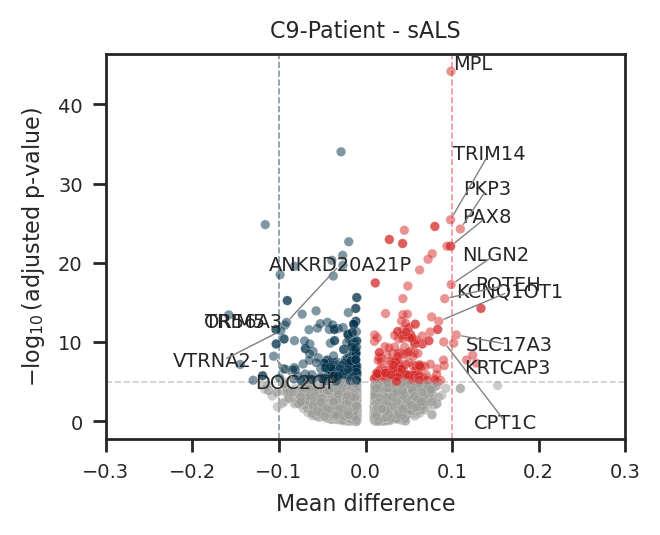

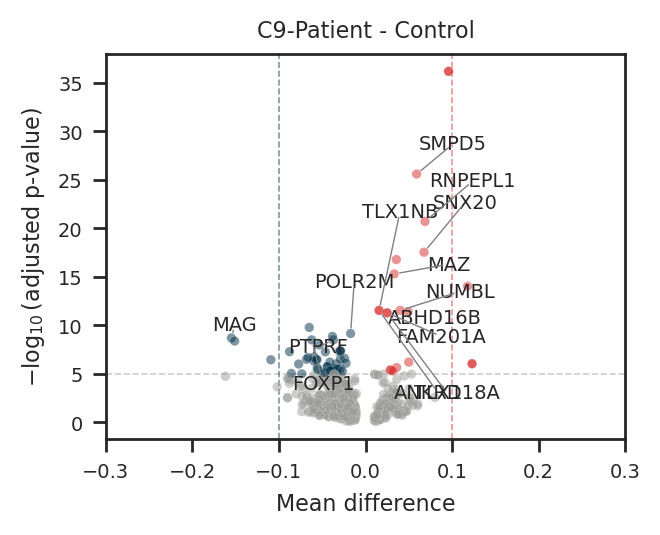

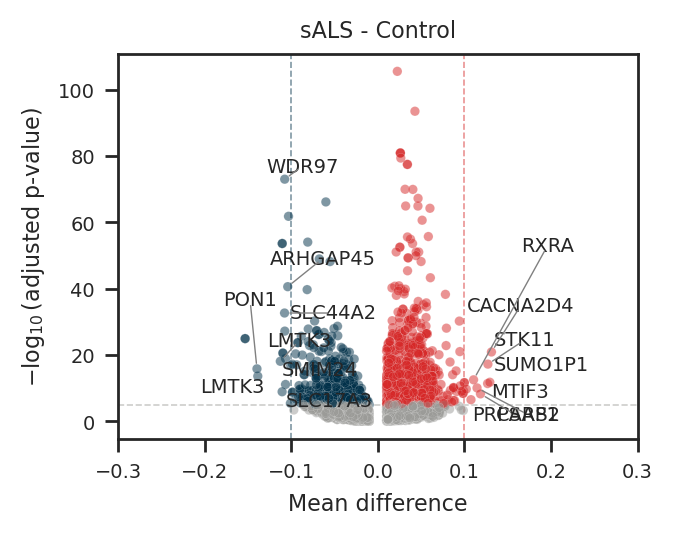

In [45]:
i = 3
for i in range(4):
    group_A, group_B = [
        ("C9-Patient", "C9-Carrier"),
        ("C9-Patient", "sALS"),
        ("C9-Patient", "Control"),
        ("sALS", "Control"),
    ][i]
    plot_temp = pd.read_csv(
        f"./20241002_denovo_DMR_{group_A}_vs_{group_B}_promoter_recalculate_MWU_pvalue.tsv",
        sep="\t",
    )
    plot_temp["abs(diff)"] = plot_temp["mean difference"].abs()
    mpl.rcParams["font.family"] = "Arial"
    sns.set(context="paper", style="ticks")
    
    f, ax = plt.subplots(figsize=(3.35, 2.5))
    ax.set_xlim(-0.3, 0.3)
    # ax.set_ylim(-2, 100)
    sns.scatterplot(
        plot_temp,
        x="mean difference",
        y="-log10(q)",
        ax=ax,
        hue="hue",
        size=5,
        alpha=0.5,
        linewidth=0.1,
        palette={1: "#d62828", 0: "#9b9b98", -1: "#003049"},
    )
    
    ax.axhline(-np.log10(0.00001), zorder=0, c="#9b9b98", lw=0.6, ls="--", alpha=0.5)
    ax.axvline(0.1, zorder=0, c="#d62828", lw=0.6, ls="--", alpha=0.5)
    ax.axvline(-0.1, zorder=0, c="#003049", lw=0.6, ls="--", alpha=0.5)
    
    # ax.set(box_aspect=)
    ax.legend_ = None
    ax.set(
        title="%s - %s" % (group_A, group_B),
        ylabel=r"$-\log_{10}(\mathrm{adjusted\ p\text{-}value})$",
        xlabel="Mean difference",
    )
    ax.title.set_fontsize(8)
    ax.xaxis.label.set_fontsize(8)
    ax.yaxis.label.set_fontsize(8)
    # optional: tick labels too
    ax.tick_params(axis="both", labelsize=7)
    
    # for i, point in C9_plot_temp.head(5).iterrows():
    #    ax.text(point['mean difference']-.1, point['-log10(q)']+2, str(point['annot.symbol']),size=10)
    
    texts = []
    for i, point in (
        plot_temp[
            (plot_temp["-log10(q)"] > 8)
            & (~plot_temp["annot.symbol"].str.startswith(("MIR", "LOC", "LINC")))
            & (~plot_temp["annot.symbol"].str.contains("AS"))
        ]
        .sort_values(by="abs(diff)", ascending=False)[
            ["mean difference", "-log10(q)", "annot.symbol"]
        ]
        .drop_duplicates()
        .head(15)
        .iterrows()
    ):
        if point["mean difference"] > 0:
            ha = "left"
        else:
            ha = "right"
        texts.append(
            ax.text(
                point["mean difference"],
                point["-log10(q)"],
                str(point["annot.symbol"]),
                size=7,
                ha=ha,
            )
        )
    
    
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.5),
        expand_text=(1.2, 1.4),
        expand_points=(1.1, 1.3),
        force_text=(0.0, 1.5),  # mostly vertical push
        force_points=(0.3, 0.6),
        lim=20000,
        prevent_crossings=True,
        only_move={"text": "y"},  # key: prevent drifting across x=0
    )
    
    f.savefig(f"./{group_A}_{group_B}_recalculate_MWUp_volvano.svg", bbox_inches="tight")